In [9]:
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx',
                   seed=42,
                   verbose=False):

    rng = np.random.default_rng(seed)

    N = 2500

    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days
    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')
    age = rng.normal(35, 10, N).clip(18, 75).round().astype(float)

    genders = np.array(['Male', 'Female', 'Other'])
    gender = rng.choice(genders, N, p=[0.48, 0.48, 0.04])

    cities = [
        'Hyderabad', 'Bangalore', 'Mumbai', 'Delhi',
        'Chennai', 'Pune', 'Kolkata', 'Ahmedabad',
        'Jaipur', 'Lucknow', 'Surat', 'Other'
    ]
    city = rng.choice(cities, N)

    transactions = []

    for i in range(N):

        customer_id = cust[i]
        num_orders = rng.poisson(5)
        if rng.random() < 0.12:
            num_orders = 0

        for j in range(num_orders):
            signup_date = signup[i]

            available_days = max(
                1,
                (end - signup_date).days
            )

            order_date = signup_date + pd.Timedelta(
                days=int(rng.integers(1, available_days + 1))
            )

            amount = rng.lognormal(
                mean=3.8,
                sigma=0.8
            )

            transactions.append({
                'customer_id': customer_id,
                'order_date': order_date,
                'amount': round(amount, 2)
            })

    transactions_df = pd.DataFrame(transactions)
    if len(transactions_df) > 0:

        order_summary = (
            transactions_df
            .groupby('customer_id')
            .agg(
                num_orders=('amount', 'count'),
                total_spend=('amount', 'sum'),
                last_order_date=('order_date', 'max')
            )
            .reset_index()
        )

    else:

        order_summary = pd.DataFrame(
            columns=[
                'customer_id',
                'num_orders',
                'total_spend',
                'last_order_date'
            ]
        )

    cust_df = pd.DataFrame({
        'customer_id': cust,
        'signup_date': signup,
        'age': age,
        'gender': gender,
        'city': city
    })
    cust_df = cust_df.merge(
        order_summary,
        on='customer_id',
        how='left'
    )

    cust_df['num_orders'] = cust_df['num_orders'].fillna(0)
    cust_df['total_spend'] = cust_df['total_spend'].fillna(0)
    cust_df['recency_days'] = (
        end - cust_df['last_order_date']
    ).dt.days
    cust_df['recency_days'] = cust_df['recency_days'].fillna(999)
    support_lambda = (
        1
        + 0.15 * cust_df['recency_days'].clip(0, 100)
    )

    cust_df['support_tickets'] = rng.poisson(
        support_lambda
    )
    churn_score = (
        -2.0
        + 0.025 * cust_df['recency_days'].clip(0, 180)
        - 0.18 * cust_df['num_orders'].clip(0, 15)
        + 0.20 * cust_df['support_tickets']
    )

    churn_probability = 1 / (1 + np.exp(-churn_score))

    cust_df['is_churned'] = (
        rng.random(N) < churn_probability
    ).astype(int)

    missing_age = rng.random(N) < 0.05
    missing_gender = rng.random(N) < 0.04
    missing_city = rng.random(N) < 0.03

    cust_df.loc[missing_age, 'age'] = np.nan
    cust_df.loc[missing_gender, 'gender'] = np.nan
    cust_df.loc[missing_city, 'city'] = np.nan
    cust_df.to_csv(csv_path, index=False)
    transactions_df.to_excel(xlsx_path, index=False)

    if verbose:
        print("Datasets created successfully.")
        print("Customer rows:", len(cust_df))
        print("Transaction rows:", len(transactions_df))

    return cust_df, transactions_df

if not os.path.exists('ecommerce_customers.csv') or \
   not os.path.exists('transactions.xlsx'):

    customers, transactions = build_datasets(
        verbose=True
    )

else:

    customers = pd.read_csv(
        'ecommerce_customers.csv'
    )

    transactions = pd.read_excel(
        'transactions.xlsx'
    )

print("\nCustomer Dataset:")
print(customers.head())

print("\nTransaction Dataset:")
print(transactions.head())

customers['signup_date'] = pd.to_datetime(
    customers['signup_date']
)

customers['last_order_date'] = pd.to_datetime(
    customers['last_order_date']
)

transactions['order_date'] = pd.to_datetime(
    transactions['order_date']
)

features = [
    'age',
    'gender',
    'city',
    'num_orders',
    'total_spend',
    'recency_days',
    'support_tickets'
]

X = customers[features].copy()
y = customers['is_churned'].copy()

print("\nFeature Matrix X:")
print(X.head())

print("\nTarget y:")
print(y.head())

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

print("\nMissing Values:")
print(X.isnull().sum())

X_encoded = pd.get_dummies(
    X,
    columns=['gender', 'city'],
    dummy_na=True
)

print("\nEncoded Feature Matrix:")
print(X_encoded.head())

print("\nEncoded Feature Matrix Shape:")
print(X_encoded.shape)

print("\n" + "=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)
possible_leakage = [
    'is_churned',
    'churn',
    'churn_date',
    'cancellation_date',
    'future_purchase',
    'future_revenue'
]

print("\nChecking feature names:")

for column in X_encoded.columns:

    if column.lower() in possible_leakage:
        print(
            "WARNING: Possible leakage found:",
            column
        )

    else:
        print(
            "OK:",
            column
        )

if 'is_churned' in X_encoded.columns:

    print(
        "\nWARNING: Target variable is present "
        "inside feature matrix!"
    )

else:

    print(
        "\nPASS: Target variable is NOT present "
        "inside feature matrix."
    )

numeric_features = X_encoded.select_dtypes(
    include=np.number
)

correlation = numeric_features.corrwith(y)

print("\nFeature Correlation With Target:")
print(
    correlation
    .sort_values(ascending=False)
)

duplicate_count = X_encoded.duplicated().sum()

print("\nDuplicate Feature Rows:", duplicate_count)
print("\n" + "=" * 60)
print("FINAL FEATURE MATRIX")
print("=" * 60)

print("Rows:", X_encoded.shape[0])
print("Columns:", X_encoded.shape[1])

print("\nFinal Features:")
print(list(X_encoded.columns))

print("\nFirst 10 rows:")
print(X_encoded.head(10))
leakage_found = []

for column in X_encoded.columns:

    column_lower = column.lower()

    if (
        'churn' in column_lower
        or 'cancel' in column_lower
        or 'future' in column_lower
    ):
        leakage_found.append(column)


print("\n" + "=" * 60)
print("LEAKAGE SUMMARY")
print("=" * 60)

if len(leakage_found) == 0:

    print("No obvious target leakage detected.")

else:

    print("Possible leakage columns:")
    for column in leakage_found:
        print("-", column)


print("\nProgram completed successfully.")

Datasets created successfully.
Customer rows: 2500
Transaction rows: 11040

Customer Dataset:
  customer_id signup_date   age gender       city  num_orders  total_spend  \
0   CUST00001  2021-04-19  18.0   Male      Other         6.0       167.02   
1   CUST00002  2023-07-31  21.0   Male       Pune         6.0       270.80   
2   CUST00003  2023-03-07   NaN   Male      Surat         8.0       231.34   
3   CUST00004  2022-06-18  18.0   Male    Kolkata         8.0       479.97   
4   CUST00005  2022-06-11  23.0   Male  Ahmedabad         5.0       325.40   

  last_order_date  recency_days  support_tickets  is_churned  
0      2024-06-09          21.0                3           0  
1      2024-05-29          32.0                8           1  
2      2024-06-24           6.0                2           0  
3      2024-06-21           9.0                1           0  
4      2024-05-23          38.0                4           1  

Transaction Dataset:
  customer_id order_date  amount
0   

In [13]:
import pandas as pd
data = {
    'customer_id': [101, 102, 103],
    'signup_date': ['2024-01-10', '2024-02-15', '2024-03-20'],
    'first_order': ['2024-01-12', '2024-02-20', '2024-03-25'],
    'last_order': ['2024-06-10', '2024-07-15', '2024-08-20'],
    'age': [25, 32, 28],
    'gender': ['Female', 'Male', 'Female'],
    'city': ['Hyderabad', 'Chennai', 'Bangalore'],
    'plan': ['Premium', 'Basic', 'Premium'],
    'device': ['Mobile', 'Laptop', 'Mobile'],
    'payment_method': ['UPI', 'Card', 'Cash'],
    'num_orders': [15, 8, 20],
    'total_spend': [15000, 7000, 22000],
    'support_tickets': [2, 1, 3],
    'email_opt_in': [True, False, True],
    'is_churned': [False, True, False]
}

df = pd.DataFrame(data)
df = df.rename(columns={
    'first_order': 'first_order_date',
    'last_order': 'last_order_date'
})
for c in ['signup_date', 'first_order_date', 'last_order_date']:
    df[c] = pd.to_datetime(df[c], errors='coerce').dt.strftime('%Y-%m-%d')
df = df[
    [
        'customer_id',
        'signup_date',
        'first_order_date',
        'last_order_date',
        'age',
        'gender',
        'city',
        'plan',
        'device',
        'payment_method',
        'num_orders',
        'total_spend',
        'support_tickets',
        'email_opt_in',
        'is_churned'
    ]
]
print(df)

   customer_id signup_date first_order_date last_order_date  age  gender  \
0          101  2024-01-10       2024-01-12      2024-06-10   25  Female   
1          102  2024-02-15       2024-02-20      2024-07-15   32    Male   
2          103  2024-03-20       2024-03-25      2024-08-20   28  Female   

        city     plan  device payment_method  num_orders  total_spend  \
0  Hyderabad  Premium  Mobile            UPI          15        15000   
1    Chennai    Basic  Laptop           Card           8         7000   
2  Bangalore  Premium  Mobile           Cash          20        22000   

   support_tickets  email_opt_in  is_churned  
0                2          True       False  
1                1         False        True  
2                3          True       False  


In [15]:
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'customer_id': range(1, 11),
    'age': [21, 25, 30, 28, 35, 40, 24, 32, 27, 29],
    'gender': ['Male', 'Female', 'Male', 'Female', 'Male',
               'Female', 'Male', 'Female', 'Male', 'Female'],
    'city': ['Hyderabad', 'Chennai', 'Mumbai', 'Delhi', 'Pune',
             'Bangalore', 'Hyderabad', 'Chennai', 'Mumbai', 'Delhi'],
    'is_churned': [0, 1, 0, 0, 1, 0, 1, 0, 0, 1]
})
rng = np.random.default_rng(42)
N = len(df)
def punch(col, frac):
    idx = rng.choice(N, int(frac * N), replace=False)
    df.loc[idx, col] = np.nan

punch('age', 0.07)
punch('gender', 0.04)
punch('city', 0.02)
print("Data after injecting missing values:")
print(df)
print("\nMissing values in each column:")
print(df.isnull().sum())

Data after injecting missing values:
   customer_id  age  gender       city  is_churned
0            1   21    Male  Hyderabad           0
1            2   25  Female    Chennai           1
2            3   30    Male     Mumbai           0
3            4   28  Female      Delhi           0
4            5   35    Male       Pune           1
5            6   40  Female  Bangalore           0
6            7   24    Male  Hyderabad           1
7            8   32  Female    Chennai           0
8            9   27    Male     Mumbai           0
9           10   29  Female      Delhi           1

Missing values in each column:
customer_id    0
age            0
gender         0
city           0
is_churned     0
dtype: int64


In [16]:
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'customer_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'age': [25, 32, 28, 45, 22, 39, 31, np.nan, 27, 150],
    'num_orders': [10, 5, 8, 12, 3, 7, 15, 4, 9, 6],
    'total_spend': [5000, 2500, 4000, 7000, 1200, 3500, 8000, 2000, 4500, 3000],
    'support_tickets': [1, 2, 0, 3, 1, 2, 4, 0, 1, 2],
    'is_churned': [0, 1, 0, 0, 1, 0, 1, 0, 0, 1]
})
print("1. Is customer_id unique?")

if df['customer_id'].is_unique:
    print("Yes, customer_id is unique.")
else:
    print("No, customer_id contains duplicate values.")
print("\n2. Numeric Summary:")
print(df.describe())
print("\n3. Three issues I can see:")

print("- Age contains a missing value.")
print("- Age contains an unrealistic value (150).")
print("- The data should be checked for duplicate customer records.")
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate customer IDs:")
print(df['customer_id'].duplicated().sum())

1. Is customer_id unique?
Yes, customer_id is unique.

2. Numeric Summary:
       customer_id         age  num_orders  total_spend  support_tickets  \
count     10.00000    9.000000   10.000000    10.000000        10.000000   
mean     105.50000   44.333333    7.900000  4070.000000         1.600000   
std        3.02765   40.255434    3.725289  2148.410265         1.264911   
min      101.00000   22.000000    3.000000  1200.000000         0.000000   
25%      103.25000   27.000000    5.250000  2625.000000         1.000000   
50%      105.50000   31.000000    7.500000  3750.000000         1.500000   
75%      107.75000   39.000000    9.750000  4875.000000         2.000000   
max      110.00000  150.000000   15.000000  8000.000000         4.000000   

       is_churned  
count   10.000000  
mean     0.400000  
std      0.516398  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      1.000000  

3. Three issues I can see:
- Age contains a missing value.


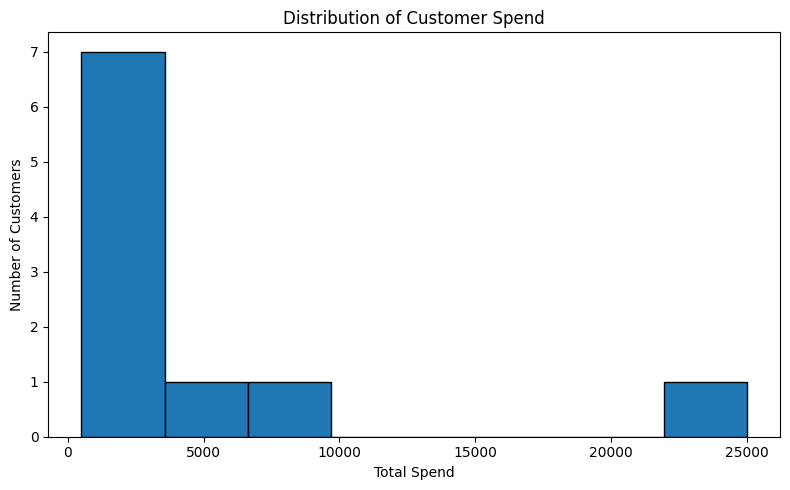

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame({
    'customer_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'total_spend': [500, 700, 900, 1200, 1500, 2000, 2500, 4000, 8000, 25000]
})

plt.figure(figsize=(8, 5))

plt.hist(df['total_spend'], bins=8, edgecolor='black')

plt.title('Distribution of Customer Spend')
plt.xlabel('Total Spend')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

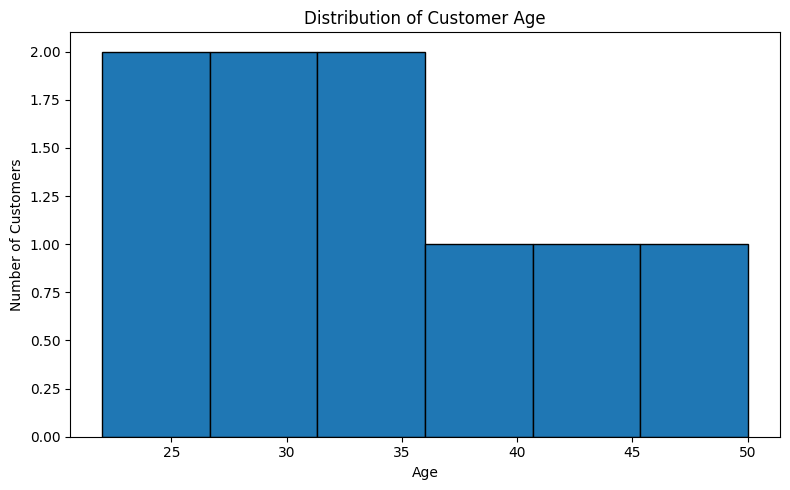

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame({
    'customer_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'age': [22, 25, 28, 30, 32, 35, 38, 42, None, 50]
})

plt.figure(figsize=(8, 5))

plt.hist(df['age'].dropna(), bins=6, edgecolor='black')

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

Mean Spend   : 4630.0
Median Spend : 1750.0

The data is right-skewed.
The mean is higher than the median because of high spenders.


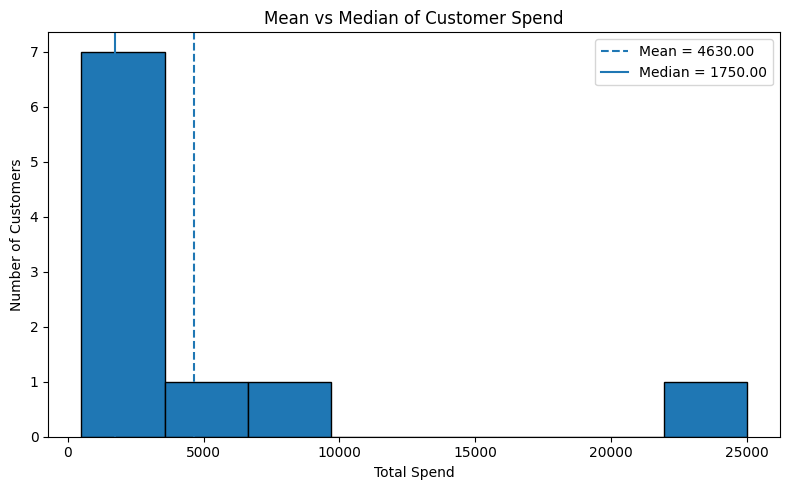

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame({
    'customer_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'total_spend': [500, 700, 900, 1200, 1500, 2000, 2500, 4000, 8000, 25000]
})

mean_spend = df['total_spend'].mean()
median_spend = df['total_spend'].median()

print("Mean Spend   :", mean_spend)
print("Median Spend :", median_spend)
if mean_spend > median_spend:
    print("\nThe data is right-skewed.")
    print("The mean is higher than the median because of high spenders.")
else:
    print("\nThe mean and median are similar.")
plt.figure(figsize=(8, 5))

plt.hist(df['total_spend'], bins=8, edgecolor='black')

plt.axvline(mean_spend, linestyle='--',
            label=f'Mean = {mean_spend:.2f}')

plt.axvline(median_spend, linestyle='-',
            label=f'Median = {median_spend:.2f}')

plt.title('Mean vs Median of Customer Spend')
plt.xlabel('Total Spend')
plt.ylabel('Number of Customers')
plt.legend()

plt.tight_layout()
plt.show()

Category Frequencies:
plan
Basic       4
Premium     4
Standard    2
Name: count, dtype: int64


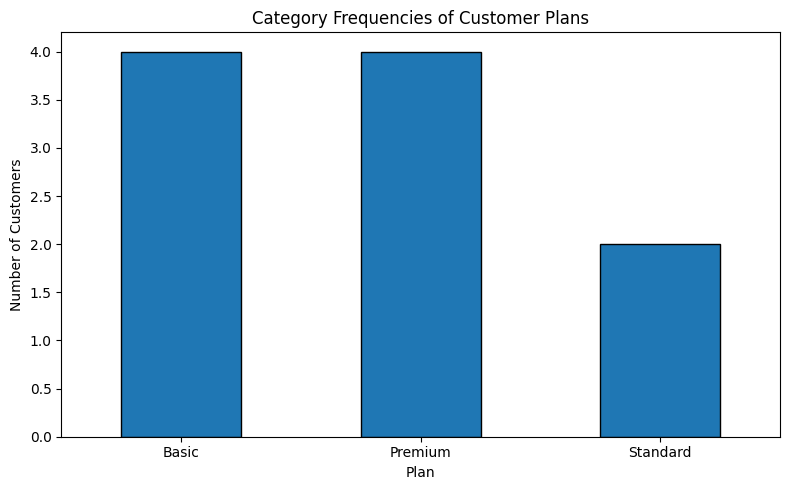

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame({
    'customer_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'plan': [
        'Basic', 'Premium', 'Basic', 'Standard', 'Premium',
        'Basic', 'Premium', 'Standard', 'Basic', 'Premium'
    ]
})
category_frequency = df['plan'].value_counts()

print("Category Frequencies:")
print(category_frequency)

plt.figure(figsize=(8, 5))

category_frequency.plot(kind='bar', edgecolor='black')

plt.title('Category Frequencies of Customer Plans')
plt.xlabel('Plan')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()